In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os
import glob
import pandas as pd
import datetime
import numpy as np

# 파일 용량 확인
def get_csv_file_sizes(DIR):
    file_sizes = {}
    for filename in os.listdir(DIR):
        if filename.endswith('.csv'):
            file_path = os.path.join(DIR, filename)
            file_size_bytes = os.path.getsize(file_path)
            file_size_mb = file_size_bytes / (1024 * 1024)
            file_sizes[filename] = file_size_mb
    return file_sizes

# 주제 1. 국내 채용시장 및 채용 플랫폼 이용패턴 분석

In [ ]:
DIR = '../topic1'
csv_file_sizes = get_csv_file_sizes(DIR)
sorted_dict = dict(sorted(csv_file_sizes.items(), key=lambda item: item[1], reverse=True))
for filename, size in sorted_dict.items():
    print(f'{filename:<30}: {size:.2f} MB')

log_2022.csv                  : 1191.35 MB
log_2023.csv                  : 845.92 MB
Application.csv               : 56.91 MB
JobBookmark.csv               : 38.88 MB
Job.csv                       : 23.10 MB
Company.csv                   : 4.19 MB
CompanyAddress.csv            : 1.21 MB
CompanyFund.csv               : 0.70 MB
JobAddress.csv                : 0.35 MB


In [ ]:
DATA_DIR = '../topic1/' # 데이터 모아둔 폴더 경로

# Company.csv
- 기업 마스터 테이블
- 기업id, 기업 생성일, 마지막 기업 정보 수정일, 설립일, 구성원 수, 기업 팔로워 수, 기업 추천 수


| 컬럼명            | 데이터 타입 | 설명                              |
|-------------------|-------------|-----------------------------------|
| id                | INTEGER     | 기업 id (PK, company_id)         |
| cdate             | DATETIME    | 기업 생성일(UTC), 플랫폼에 기업 정보 등록한 시점 |
| mdate             | DATETIME    | 마지막 기업정보 수정일           |
| found_date        | DATE        | 설립일(KST)                       |
| employee_count    | STRING      | 구성원 수, 데이터 수집 시점에 집계된 숫자 |
| view_count        | INTEGER     | 기업 정보 조회수, 데이터 수집 시점에 집계된 숫자 |
| follow_count      | INTEGER     | 기업 팔로우 수, 데이터 수집 시점에 집계된 숫자 |
| reference_count   | INTEGER     | 기업 추천 수, 데이터 수집 시점에 집계된 숫자 |


In [ ]:
company = pd.read_csv(DATA_DIR + 'Company.csv')
company.head()

,cdate,mdate,found_date,employee_count,view_count,follow_count,reference_count,company_uuid
0,2022-06-09 04:08:40,2022-06-09 04:08:40,NaN,0명,0,0,0,c46f2fa5-f940-40fb-bd4a-aa0ff7a837fd
1,2017-05-22 10:57:12,2022-07-25 00:12:02,NaN,0명,256,0,0,725e87bb-de2f-416a-a6b8-1ca8d0d096e0
2,2017-11-14 11:42:55,2022-11-04 03:29:16,NaN,0명,256,0,0,efa3747d-9bbd-4c84-af51-82ccf6545dcd
3,2017-11-27 10:59:30,2021-01-17 14:42:06,NaN,0명,256,0,0,84aa2c20-d0f3-4ec3-ac06-1ef67e071b8f
4,2018-01-08 14:41:58,2022-07-25 01:34:16,2018-01-08,0명,256,0,0,761e76b3-507c-4c8f-b96f-fa47a8ccb5f2


In [ ]:
company.isnull().sum()

cdate                  0
mdate                  0
found_date         24175
employee_count         0
view_count             0
follow_count           0
reference_count        0
company_uuid           0
dtype: int64

설립일 결측치가 많다

In [ ]:
company.nunique()

cdate              41329
mdate              35488
found_date          5199
employee_count         8
view_count          6830
follow_count         458
reference_count       63
company_uuid       41659
dtype: int64

기업의 uuid는 모두 유니크하다

In [ ]:
company['employee_count'].value_counts()

employee_count
0명            34978
1-10명          3202
11-50명         2589
51-200명         673
201-500명        125
501-1000명        42
1001-5000명       40
5000명 초과         10
Name: count, dtype: int64

사원수는 0명- 아마 미수집 데이터 일듯한데 가장 많다

In [ ]:
company[['view_count','follow_count','reference_count']].describe().loc[['mean','max','min','50%']].round(1)

,view_count,follow_count,reference_count
mean,1661.8,10.2,0.7
max,575596.0,2740.0,249.0
min,0.0,0.0,0.0
50%,536.0,0.0,0.0


업체 조회수, 팔로우수, 추천수의 분포 확인
- 추천수는 대체도 응답을 하지 않는다
- 인기 기업의 경우 큰 조회수와 팔로우 수를 가진다.
- 인기 기업을 세 컬럼중 적당히 큰 숫자를 가지는 기업으로 두고 해당 기업을 그룹핑하여 분석해볼만 하다

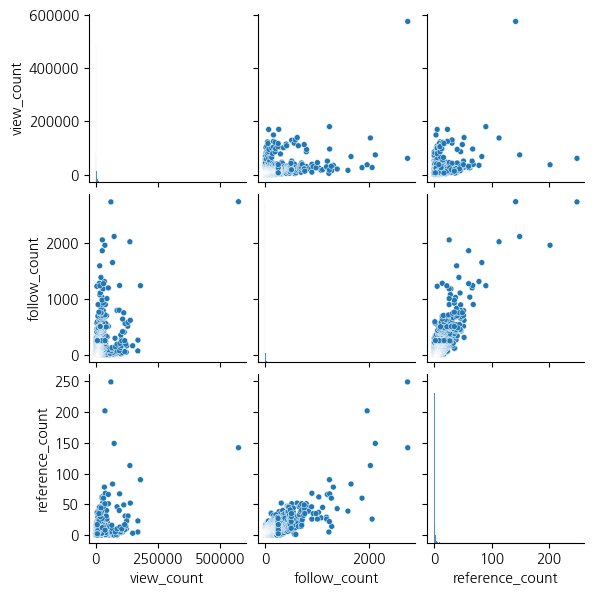

In [ ]:
sns.pairplot(company[['view_count','follow_count','reference_count']],height=2,plot_kws={'size':0.5})
plt.show()

변수간 선형성을 일부 보임, 낮은 숫자에 데이터가 몰려있어서 적당히 구분지어서 추가적으로 확인해볼 필요있음

In [ ]:
company['cdate'].min(),company['cdate'].max()

('2013-01-10 15:47:37', '2023-12-31 09:59:24')

기업등록 시점의 최소 최대값
- 등록시점에 따른 기업 평판 (조회,팔로우,추천) 숫자가 다른지 확인해볼 여지있음
- 설립일과 비교를 통해 설립시점으로 부터 해당 플랫폼에 등록한 시점의 차이의 분포를 통해 플랫폼의 평판을 확인해볼 수 있음

# CompanyAddress.csv
- 기업 주소지 정보 테이블	기업id
- 기업 상위 주소지 정보, 주소지명(Ex. 본사)
1. 수도권 (서울 + 경기도): **구**까지 제공  
2. 광역시(수도권 제외): **시**까지 제공  
3. 그 외 지역: **도**까지 제공  
4. 해외 본사: **나라명**까지 제공  

| 컬럼명      | 데이터 타입 | 설명 |
|------------|------------|----------------------------------------------------------------|
| company_id | INTEGER    | 기업 id |
| address1   | STRING     | 주소(상위 정보) |
| name       | STRING     | 주소지명 (Ex: 본사, 연구소 등) |




In [ ]:
CompanyAddress = pd.read_csv(DATA_DIR + 'CompanyAddress.csv')
CompanyAddress.head()

,name,company_uuid,address
0,NaN,0bf81092-9bb5-44c7-a8de-e1db103253ef,서울 구로구
1,사무실,0bf81092-9bb5-44c7-a8de-e1db103253ef,서울특별시 구로구
2,NaN,e8b24030-b0c5-4f07-9427-2d1e2519cb82,"158 Hoàng Hoa Thám, Phường 12, Tân Bình, Hồ Ch..."
3,NaN,21743ac5-8957-4b2e-8f36-804d187d75a5,서울특별시 서초구
4,NaN,82be7598-af6f-4af9-86d5-f57ccb76f8dd,서울특별시 종로구


In [ ]:
CompanyAddress.isnull().sum()

name            279
company_uuid      0
address           0
dtype: int64

주소지명 결측치가 일부 존재

In [ ]:
CompanyAddress.company_uuid.value_counts()

company_uuid
39db3d5b-4e84-4c52-a68d-c097d859542d    44
43408a24-5a2e-464a-b868-d50f39651262    33
9de72f52-dc33-4400-a11e-1bd08672b2ec    30
e47b6773-6d74-4086-bd48-a9523655d0b3    21
47990a4b-3d21-431b-a465-cecbc4b67de3    19
                                        ..
b541c3df-865c-4e19-be97-fb1d998b55e5     1
5bd7f710-98aa-4882-8d3e-475f4bb96304     1
6ccfbd5f-2d45-4781-9ec6-44a9c58b8b97     1
d239d00b-de68-42f6-847f-dc23a0729d3d     1
998303dc-9145-4be3-aad8-909969684479     1
Name: count, Length: 14033, dtype: int64

1개 기업은 최대 44개의 주소를가짐

In [ ]:
CompanyAddress[CompanyAddress['company_uuid'] =='39db3d5b-4e84-4c52-a68d-c097d859542d']

,name,company_uuid,address
14551,르호봇 강남 비즈니스 센터,39db3d5b-4e84-4c52-a68d-c097d859542d,서울특별시 강남구
14552,르호봇 광주 비즈니스 센터,39db3d5b-4e84-4c52-a68d-c097d859542d,광주광역시 서구
14553,르호봇 교대 비즈니스 센터,39db3d5b-4e84-4c52-a68d-c097d859542d,서울특별시 서초구
14554,르호봇 구의 비즈니스 센터,39db3d5b-4e84-4c52-a68d-c097d859542d,서울특별시 광진구
14555,르호봇 대구 비즈니스 센터,39db3d5b-4e84-4c52-a68d-c097d859542d,대구광역시 중구
14556,르호봇 대림 원투피스 센터,39db3d5b-4e84-4c52-a68d-c097d859542d,서울특별시 구로구
14557,르호봇 대전 비즈니스 센터,39db3d5b-4e84-4c52-a68d-c097d859542d,대전광역시 서구
14558,르호봇 부산 비즈니스 센터,39db3d5b-4e84-4c52-a68d-c097d859542d,부산광역시 부산진구
14559,르호봇 사당 비즈니스 센터,39db3d5b-4e84-4c52-a68d-c097d859542d,서울특별시 서초구
14560,르호봇 삼성 비즈니스 센터,39db3d5b-4e84-4c52-a68d-c097d859542d,서울특별시 강남구


분점이 많은 경우 동일 uuid에 대해 여러 주소를 가짐

In [ ]:
print(f'주소 존재하는 회사 id 수 : {CompanyAddress.company_uuid.nunique()} , 전체 회사 id 수 { company.company_uuid.nunique()}')

주소 존재하는 회사 id 수 : 14033 , 전체 회사 id 수 41659


모든 회사id에 대해 주소를 가지는 것은 아님

In [ ]:
CompanyAddress.address.str.split(' ').str[0].value_counts()

address
서울특별시     12226
성남시        1050
서울          633
부산광역시       306
대전광역시       270
          ...  
175           1
409           1
Omlaat        1
100           1
P.            1
Name: count, Length: 295, dtype: int64

주소가 다양하게 들어가 있음 정규표현식등을 활용해서 한글 / 그 외를 구분하고 살펴봐야 할 듯

# CompanyFund.csv
- 기업id, 투자유치일, 투자단계, 투자유치금, 통화(KRW/USD)

| 컬럼명       | 데이터 타입 | 설명       | Comment |
|-------------|------------|------------|----------------------------------------------------------------|
| company_id  | INTEGER    | 기업 id    |  |
| date        | DATE       | 투자일(KST) |  |
| round_type  | STRING     | 투자 단계  | 투자 단계 비공개, Seed, Angel, Series A, Series B, Series C, Series D, Pre-IPO, 해당없음 중 하나 |
| raised      | INTEGER    | 투자 금액   |  |
| currency    | STRING     | 원화/달러   | KRW, USD |


In [ ]:
CompanyFund =pd.read_csv(DATA_DIR +'CompanyFund.csv')
CompanyFund.shape

(9182, 5)

In [ ]:
CompanyFund.isnull().sum()

fund_date         0
round_type        0
raised            0
currency        103
company_uuid      0
dtype: int64

In [ ]:
CompanyFund.company_uuid.nunique()

4785

전체회사 41659개 중 투자 관련 정보가 있는 회사는 4785개뿐

In [ ]:
CompanyFund['currency'].unique()

array(['KRW', nan, 'USD'], dtype=object)

투자 금액은 KRW,USD, nan 타입

In [ ]:
CompanyFund['round_type'].unique()

array(['Seed', 'Angel', '투자 단계 비공개', 'Series A', '해당없음', 'Series B',
       'Series C', 'Series D', 'Pre-IPO'], dtype=object)

다양한 투자 단계에 대해 값들이 존재

In [ ]:
CompanyFund[(CompanyFund.raised == 0)].round_type.value_counts()

round_type
투자 단계 비공개    2090
Seed         1104
Angel         262
Series A      227
해당없음          126
Series B       33
Pre-IPO         8
Series C        6
Series D        1
Name: count, dtype: int64

다양한 round 단계에 대해 투자금액이 0원으로 (미공개?) 있는 경우가 있다. 투자 금액자체를 활용하기에는 누락 데이터가 많아 보임 / round 단계 정도로 파악해야함

# Job.csv
- 채용공고 마스터 테이블
- 용공고id, 기업id, 생성일, 마지막 수정일, 채용분야, 채용시작일, 채용마감일, 경력, 연봉공개여부, 원격근무가능여부

| 컬럼명                | 데이터 타입 | 설명                 | Comment |
|----------------------|------------|----------------------|--------------------------------------------------------------|
| id                  | INTEGER    | 채용공고 id          | PK (job_id) |
| company_id          | INTEGER    | 기업 id              |  |
| cdate              | DATETIME   | 등록 날짜(KST)       |  |
| mdate              | DATETIME   | 마지막 수정일(KST)   | 수정하지 않았을 경우, cdate와 동일 |
| job_field          | STRING     | 업무분야             | SW 개발, 기획/PM, 마케팅, 디자인, 운영, 경영지원, 비즈니스, 투자, HW 개발, 게임 개발 중 하나 |
| career_type_string | STRING     | 경력 형태            | 인턴, 신입, 경력 중 1개 이상 선택 |
| start_date        | DATE       | 채용시작일(KST)      | 등록 날짜와 동일 |
| end_date          | DATE       | 채용마감일(KST)      |  |
| allow_remote      | INTEGER    | 원격근무 가능 여부   | 원격근무 가능 : 1, 원격근무 불가능 : 0 |
| can_show_salary   | INTEGER    | 연봉 공개 여부       | 연봉공개 : 1, 연봉비공개 : 0 |


In [ ]:
job = pd.read_csv(DATA_DIR + 'Job.csv')
display(job.head())
job.shape

,cdate,mdate,job_field,career_type_string,start_date,end_date,allow_remote,can_show_salary,job_uuid,company_uuid
0,2020-11-25 10:32:10,2020-11-25 10:32:10,SW 개발,"신입,경력,인턴",NaN,2020-11-25,1,0,764292b0-53f8-4f14-ac83-6eafc7a6a18d,daa34559-fc42-47f6-b5c6-cc6171404f37
1,2020-12-03 16:24:16,2020-12-03 16:24:16,HW 개발,인턴,2020-12-03,2020-12-04,1,0,b2b598d6-9ca3-4eb4-ac9c-bb57a6dad2ad,daa34559-fc42-47f6-b5c6-cc6171404f37
2,2019-06-13 08:47:25,2019-06-13 08:47:25,디자인,"신입,경력,인턴",2019-06-13,2019-06-21,0,0,017f4d7d-91a9-4ef7-9dd7-afabf7cbd26d,d4e7e647-8f85-4e7f-8609-7173cc240e18
3,2019-06-14 01:34:45,2019-07-02 00:28:35,마케팅,경력,2019-06-14,2019-07-15,0,0,41707ef1-f733-4f58-bb29-0b2e6175cf5e,d4e7e647-8f85-4e7f-8609-7173cc240e18
4,2019-07-02 00:28:58,2019-07-16 13:03:08,운영,"신입,경력",2019-07-02,2019-08-31,0,0,d0aa0eef-65d2-4e00-8177-968a2dc52009,d4e7e647-8f85-4e7f-8609-7173cc240e18


(144247, 10)

In [ ]:
job.mdate.min() , job.mdate.max()

('2013-01-10 15:48:38', '2024-05-05 13:22:19')

지원 공고 일자 최소 최대, 2013년도는 뭐야..

In [ ]:
job.isnull().sum()

cdate                     0
mdate                     0
job_field                 0
career_type_string        0
start_date            43531
end_date              22718
allow_remote              0
can_show_salary           0
job_uuid                  0
company_uuid              0
dtype: int64

시작,종료일이 없는 경우가 존재, 시작일보다 종료일이 더 없다 -> 시작일은 공고 올린날로 봐도 무방할듯

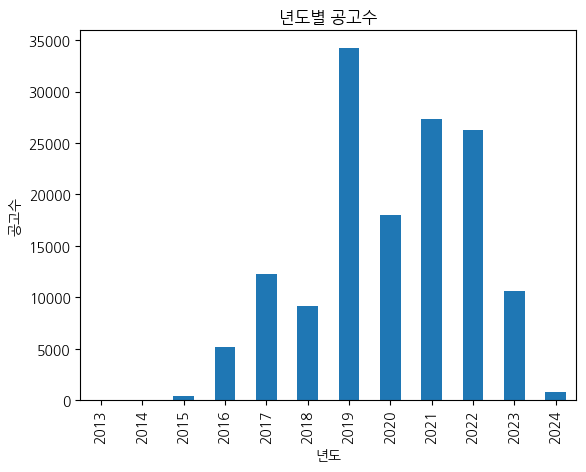

In [ ]:
pd.to_datetime(job['mdate']).dt.year.value_counts().sort_index().plot(kind = 'bar')
plt.xlabel('년도')
plt.ylabel("공고수")
plt.title('년도별 공고수')
plt.show()

서비스 로그가 22,23년도 뿐인데 ㅂㄷㅂㄷ ;;
19년도 피크 이유와 코로나 시즌에 추세를 따로 구분지어 살펴볼 필요가 있다

In [ ]:
job['job_uuid'].nunique() ==job.shape[0]

True

job_uuid가 job의 행 숫자와 동일 (모두 유니크하다)

In [ ]:
job['company_uuid'].value_counts()

company_uuid
7e62c1ea-42ed-4654-b113-52157d329fcc    3495
3d6730ee-b869-47b7-90c6-1e074e4eb15b    2266
5b00ba89-7ffc-403b-a35e-01371a962dd3    1306
997dea23-cc15-4af7-8f9b-33dc2e6cf1ac    1197
18046276-13b0-462b-bab5-7db92aad9690     883
                                        ... 
2f335912-20fd-4268-a4ac-f9db28892cec       1
599efd75-3b1f-4031-ae5f-ade5e48da0f4       1
f1f0da80-eb2f-47f5-be23-d01c40d78edc       1
3df3ecaa-12a7-4bb6-adc3-08b84419d808       1
c5dcb489-1713-4309-be00-d1dbf5e0101d       1
Name: count, Length: 14615, dtype: int64

한 회사에서 많은 공고를 올렸다. 추측해보면
- 특정 정기 채용때 다양한 포지션자리가 오픈
- 여러기간(년도)에 걸쳐 채용 공고를 오픈

확인해볼만한 질문
- 기업들의 채용이 많은 시점은 언제인가?
    - job_filed,  career_type_string 구성에 따라
- 많은 공고가 동시에 열리는 기업의 특성은 무엇인가?
- 경력, 신입, 인턴에 따라 채용공고가 열리는 시점은 차이가 존재하는가?
- 원격 근무와 연봉 근무는 다른 컬럼들과 어떤 관계를 보이는가?
- 직무에 따른 공고의 특성차이가 존재하는지?

In [ ]:
job['career_type_string'].value_counts()

career_type_string
경력          74682
신입,경력       36529
신입,경력,인턴    20928
인턴           4360
신입,인턴        3373
신입           3274
경력,인턴        1101
Name: count, dtype: int64

경력공고가 많이 보인다
- 기간별, 코로나시즌, 국제정세(?) 따라 어떤 추세를 보이는지 살펴보면 좋을듯

In [ ]:
job['job_field'].value_counts()

job_field
SW 개발    58923
마케팅      19963
디자인      19872
운영       14611
기획/PM    11719
비즈니스     10459
경영지원      6541
HW 개발     1095
게임 개발      644
투자         420
Name: count, dtype: int64

소프트웨어 개발 관련한 공고가 가장 많다

# JobAddress.csv
- 채용공고 주소지 정보 테이블
- 채용공고id, 근무지 상위 주소지 정보, 근무지명

In [ ]:
jobaddress = pd.read_csv(DATA_DIR + 'JobAddress.csv')

In [ ]:
jdu = jobaddress['job_uuid'].nunique()
ju = job['job_uuid'].nunique()
print(f'채용공고 정보의 job uuid 수 : {jdu} ,  채용공고 주소지 정보의 job uuid 수  :  {ju}')

채용공고 정보의 job uuid 수 : 4898 ,  채용공고 주소지 정보의 job uuid 수  :  144247


모든 채용공고의 주소지 정보가 나와 있는것은 아니다. 대략 3%만 존재
하나의 job_uuid가 여러개의 jobaddress를 가지는 경우도 존재

In [ ]:
jobaddress[jobaddress.job_uuid =='bf207485-b1cd-4c69-bd91-6e4ac536b197']

,name,job_uuid,address
2356,사무실,bf207485-b1cd-4c69-bd91-6e4ac536b197,서울특별시 강남구
2357,사무실,bf207485-b1cd-4c69-bd91-6e4ac536b197,서울특별시 강남구
2358,사무실,bf207485-b1cd-4c69-bd91-6e4ac536b197,서울특별시 강남구
2359,사무실,bf207485-b1cd-4c69-bd91-6e4ac536b197,서울특별시 강남구
2360,사무실,bf207485-b1cd-4c69-bd91-6e4ac536b197,서울특별시 강남구
2361,사무실,bf207485-b1cd-4c69-bd91-6e4ac536b197,서울특별시 강남구
2362,사무실,bf207485-b1cd-4c69-bd91-6e4ac536b197,서울특별시 강남구
2363,사무실,bf207485-b1cd-4c69-bd91-6e4ac536b197,서울특별시 강남구
2364,사무실,bf207485-b1cd-4c69-bd91-6e4ac536b197,서울특별시 강남구
2365,사무실,bf207485-b1cd-4c69-bd91-6e4ac536b197,서울특별시 강남구


- 모든행이 중복인 데이터가 존재, drop_duplicates()로 날리고 봐야함
- 지역,시기별 공고 차이 등에 대해서 분석해볼 수 있음

# JobBookmark.csv
- 채용 북마크 트랜잭션 테이블
- 유저id, 채용공고id, 북마크일시


| 컬럼명      | 데이터 타입 | 설명                | Comment |
|------------|------------|---------------------|---------|
| user_id    | INTEGER    | 유저 id             |  |
| recruit_id | INTEGER    | 북마크한 채용 id    |  |
| cdate      | DATETIME   | 북마크 시점(UTC)    |  |


In [ ]:
jobbookmark  = pd.read_csv(DATA_DIR + 'JobBookmark.csv')
jobbookmark

,cdate,job_uuid,user_uuid
0,2018-02-11 22:17:43,e9d423cb-2b66-4c9a-83a2-4f808bb9c8db,2a4f7d22-716c-4417-b00f-e081cd33296b
1,2018-02-20 03:38:28,5b54f6d1-450d-4fca-b975-726876570e2b,2a4f7d22-716c-4417-b00f-e081cd33296b
2,2018-05-11 03:16:18,719eb06b-e616-4831-999c-e98f5269eb4c,2a4f7d22-716c-4417-b00f-e081cd33296b
3,2017-06-12 22:51:02,69420e80-c610-4d6e-b961-f1a68d60ff7e,2a4f7d22-716c-4417-b00f-e081cd33296b
4,2017-06-12 22:45:07,5af4284b-1712-49e2-81e1-a425e039c90a,2a4f7d22-716c-4417-b00f-e081cd33296b
...,...,...,...
413861,2020-02-26 15:18:14,a0ec9ae9-449c-47d1-8f04-7ead337c8597,29c91aed-1892-409a-804b-2b56144f0616
413862,2023-06-29 18:29:54,2a1f0d8f-1faa-4b1b-a0ab-cf50f0ab3a19,b9fabe1e-8c83-46fd-bba6-7ae702e9755d
413863,2024-04-03 09:54:13,69d41548-9a36-4442-84f1-187fc3df44d9,83675f11-0a6c-41ec-b634-0635437f1e9b
413864,2020-09-11 00:28:07,e9bb616c-1082-47fe-a62c-e44c963afd0f,2a4096be-df63-4675-9b6f-58f5449846f3


In [ ]:
jobbookmark['cdate'].min() ,jobbookmark['cdate'].max()

('2015-09-25 06:15:22', '2024-05-06 14:31:42')

북마크 시점의 최대 최소기간 / 위에서 살펴본 데이터 기간과 정확하게 일치하지 않는다. 특정시점 이후에 북마크 기능이 들어간듯

In [ ]:
jobbookmark.user_uuid.value_counts()

user_uuid
764148eb-ae46-4cc3-afe4-24d10541a277    930
14c2c48a-5ed6-46d4-b196-e6bfc7e436ce    865
1e0fb5e0-75e9-4446-be87-dd3fb62562be    781
d412f031-93f5-4833-8ab9-f3a5b8c4cdf5    684
fcd13431-8f24-4825-bcad-484f8eaf7537    559
                                       ... 
ec14a62d-20c4-436d-b775-82b55569b1b5      1
6a1deb88-2996-4c57-a221-71e11d7b79c2      1
3337f6af-69ed-4e0c-8eca-6f96b701b298      1
92181471-2bf7-47c7-8d0b-3025d4eca4e6      1
a0c54534-0202-4455-92b4-f2d419dff6bd      1
Name: count, Length: 53053, dtype: int64

In [ ]:
jobbookmark.user_uuid.value_counts().describe()

count    53053.000000
mean         7.800991
std         18.875778
min          1.000000
25%          1.000000
50%          3.000000
75%          7.000000
max        930.000000
Name: count, dtype: float64

user_uuid 관점     
유저가 북마크를 했다는 시점은 취업 의사가 있는 시점으로 추측할 수 있다.    
- 북마크 숫자가 비정상적으로 많은 경우는 크롤러 / 운영진 / 헤비취업자.. 등의 이상치로 보인다.    
- 유저별 북마크 숫자는 평균 7건, 중위수는 3건이다


job_uuid 관점
- 북마크가 많이 된 공고는 많은 유저들이 관심을 가지는 공고로 볼 수 있다.
    - 그러한 공고들이 가지는 특성을 분석해보기
    - 인기 공고들을 선택한 유저의 특성 분석해보기

# Application.csv

- 지원서 마스터 테이블
- 지원서id, 유저id, 채용공고id, 지원일시	현재 하나의 채용공고에 유저가 여러번 지원할 수 있음. 채용담당자가 재지원을 요구하기도 함.

| 컬럼명   | 데이터 타입 | 설명                 | Comment |
|---------|------------|----------------------|---------|
| id      | INTEGER    | 지원 id              |  |
| user_id | INTEGER    | 유저 id              |  |
| job_id  | INTEGER    | 채용 id              |  |
| cdate   | DATETIME   | 지원서 제출시간(UTC) |  |


In [ ]:
ap = pd.read_csv(DATA_DIR + 'Application.csv')
display(ap.head())
ap.shape

,cdate,company_uuid,job_uuid,user_uuid,application_uuid
0,2017-02-25 23:45:01,de4b3596-b4ab-47cd-b8ea-6f9e14170064,459e461d-a571-4ed3-8751-8f4cb5b9ff37,b0329bd7-fc45-4e83-993a-b73bd9d3549c,59c42363-f764-4cbd-aafd-20eb663ea5d7
1,2020-11-23 14:46:07,f6156b12-d4d7-469f-84be-31799c765211,e5ed4f4a-08aa-4f2d-9042-1e9bbd36803f,b0329bd7-fc45-4e83-993a-b73bd9d3549c,425db0e8-87f8-4b4d-8248-7f24c31d49d3
2,2017-10-28 22:30:11,2ed05b18-c735-474a-9faa-02095b25729a,0f636d7a-53f7-485e-8a08-33253ddab380,b0329bd7-fc45-4e83-993a-b73bd9d3549c,be4d9e85-dc53-4e70-90af-64d2d6b117d2
3,2017-07-03 17:40:05,3d6730ee-b869-47b7-90c6-1e074e4eb15b,3cade56a-6354-411a-82a6-f2c7774539c1,b0329bd7-fc45-4e83-993a-b73bd9d3549c,d43879d1-c424-4192-9eae-4537fa6687cb
4,2017-02-10 10:53:39,de4b3596-b4ab-47cd-b8ea-6f9e14170064,459e461d-a571-4ed3-8751-8f4cb5b9ff37,a7593a15-b93e-4bc3-91bf-e4074c931d33,61873fd7-f075-44c0-90fe-f6521226550d


(340730, 5)

- 공고 마감일과 제출일자 사이의 관계 (마감일에 쫓겨 제출하는가?)
- 실제 제출과 북마크는 관계가 있는지
- 채용담당자가 재지원을 요구하는 경우에 대한 케이스 확인
- 같은 회사에 여러번 다른 공고에 지원하는 경우는 얼마나 있는지 / 그러한 회사의 특징은 무엇인지

In [ ]:
ap.cdate.min() , ap.cdate.max()

('2015-02-24 10:22:28', '2023-12-31 14:45:05')

15년부터 23년까지의 데이터가 존재

In [ ]:
ap.isnull().sum()

cdate               0
company_uuid        0
job_uuid            0
user_uuid           0
application_uuid    0
dtype: int64

결측치는 없다

In [ ]:
ap.application_uuid.value_counts()

application_uuid
59c42363-f764-4cbd-aafd-20eb663ea5d7    1
45b9cd03-a9a4-4361-95f6-e49cd5865026    1
365d8bcc-8710-46ff-b960-2de9a06f2484    1
a3ea725b-839f-44ff-a72b-c36c6d7f53d1    1
a5cf1405-3ab4-45b3-b5ff-a731dd13abec    1
                                       ..
917f3ba2-ade5-4e65-be33-e61d77beaedf    1
902ded12-539a-461c-9f33-a9ec7995ee7b    1
2a8d18bf-2053-43a6-866f-555a2168b25b    1
d6e416b9-015e-4f26-aafb-e6f96aee8359    1
6c6fc132-80a2-4322-8d71-90a376f52bd7    1
Name: count, Length: 340730, dtype: int64

application_uuid는 모두 유니크하다 == 지원서는 고유하다.

# log
- log	사용자 로그 테이블
- 유저id, 이벤트 발생 화면경로, 직전 화면경로, 로그 생성 일시, HTTP 요청 메소드, HTTP 응답 코드	"구직자의 로그 데이터만 제공합니다. 로그를 통해 확인 가능한 이벤트는 아래와 같습니다.

```
구직자의 로그 데이터만 제공합니다. 로그를 통해 확인 가능한 이벤트는 아래와 같습니다.

1. 플랫폼 서비스 웹 내에서의 페이지 이동 및 이벤트 전체
*단, 개인정보 이슈상 아래 이벤트를 제외
- 메시지 수신
- 메시지 송신
- 연결신청
- 연결신청 수락 등

2. 채용서비스 관련 각종 이벤트 예시
*모두 1에 포함되는 데이터입니다.
- 채용정보 조회
- 채용 기업 페이지 조회
- 채용 기업의 구성원 프로필 조회
- 지원서 업데이트 (개인정보 이슈상, 어떤 내용이 업데이트되었는지는 미제공)
- 채용공고 북마크
```



| 컬럼명         | 데이터 타입 | 설명               | Comment |
|--------------|------------|------------------|---------|
| user_id      | INTEGER    | 유저 id          |  |
| timestamp    | TIMESTAMP  | 로그 생성 시점   |  |
| date         | DATETIME   | 로그 생성일      |  |
| path         | STRING     | 이벤트 발생 화면 경로 |  |
| response_code | INTEGER    | HTTP 응답 코드   |  |
| method       | STRING     | HTTP 요청 메소드 |  |


In [ ]:
log22 = pd.read_csv(DATA_DIR + 'log_2022.csv').sort_values(['user_uuid','timestamp']).reset_index(drop=True) # 시간순 정렬

/var/folders/0c/m1b4q_z52zld8x37by80fyv00000gn/T/ipykernel_83497/2274843739.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  log22 = pd.read_csv(DATA_DIR + 'log_2022.csv').sort_values(['user_uuid','timestamp']).reset_index(drop=True) # 시간순 정렬


In [ ]:
log22.shape

(10052895, 6)

22년 데이터는 천만행

In [ ]:
# 일부 데이터만 필터하는 방법
# chunk = pd.read_csv(directory + 'log_2022.csv',index_col = 0,chunksize=100)
# df= chunk.get_chunk()
# df.head()

In [ ]:
log22.isnull().sum()

user_uuid             0
URL              369382
timestamp             0
date                  0
response_code         0
method              370
dtype: int64

3% 결측치 존재

In [ ]:
nulls = log22[log22.URL.isnull()]

In [ ]:
nulls.response_code.value_counts()

response_code
200    339706
200     23764
404      5338
302       267
404       195
503        88
500        11
302        10
503         3
Name: count, dtype: int64

결측치 데이터 만의 특성이 따로 있지는 않는것으로 보임

In [ ]:
log22[log22['timestamp'].str.contains('2022-11-13')].sort_values('timestamp') # 특정 timestamp값이 2022-11-13으로 되

,user_uuid,URL,timestamp,date,response_code,method
16736,007e17e8-a446-4aba-877f-2d1e68a73a2e,"suggest?q=ㅇ,2022-11-13 06:38:17.472514 UTC",2022-11-13,200,GET,NaN
7790894,c2b030f6-d77b-4759-8b27-532812b6c3aa,NaN,2022-11-13 00:00:09.498185 UTC,2022-11-13,200,GET
7451435,b84c63da-0943-40df-8189-a6fec5f13abc,continue?next=/companies/gamecoach/jobs,2022-11-13 00:10:04.56943 UTC,2022-11-13,302,GET
7451436,b84c63da-0943-40df-8189-a6fec5f13abc,companies/company_id/jobs,2022-11-13 00:10:06.394351 UTC,2022-11-13,200,GET
9543722,f1738de8-9dd6-4a30-b816-ef833ca6b04d,continue?next=/@e35ae880/applications,2022-11-13 00:11:04.098385 UTC,2022-11-13,302,GET
...,...,...,...,...,...,...
7764639,c267e5ab-19e3-465d-a856-02bfce3920cd,NaN,2022-11-13 23:59:03.159532 UTC,2022-11-14,200,GET
7431389,b7c2fbca-b658-4915-b6be-2008b39af169,continue?next=/@tkksm2/applications,2022-11-13 23:59:12.397308 UTC,2022-11-14,302,GET
7431390,b7c2fbca-b658-4915-b6be-2008b39af169,@user_id/applications,2022-11-13 23:59:12.786347 UTC,2022-11-14,200,GET
8698960,d80f1efd-de66-4671-81c6-5d7e86bc9903,jobs/id/id_title,2022-11-13 23:59:19.625258 UTC,2022-11-14,200,GET


In [ ]:
log22['datetime'] = pd.to_datetime(log22['timestamp'].str.replace(' UTC','').map(lambda x: x + ' 00:00:00.000' if len(x) == 10 else (x if '.' in x else x + '.000')))
log22 = log22.drop(columns = ['timestamp'])

In [ ]:
log22.head()

,user_uuid,URL,date,response_code,method,datetime
0,0002535c-eacb-456b-a620-92c917332ba3,@user_id?action=request_approval_complete,2022-01-15,200,GET,2022-01-15 07:44:06.150657
1,0002535c-eacb-456b-a620-92c917332ba3,api/users/id/template,2022-01-15,200,POST,2022-01-15 07:44:08.578129
2,0002535c-eacb-456b-a620-92c917332ba3,@user_id?action=request_approval_complete,2022-03-01,200,GET,2022-03-01 05:45:33.359728
3,0002535c-eacb-456b-a620-92c917332ba3,api/users/id/template,2022-03-01,200,POST,2022-03-01 05:45:35.489070
4,0002535c-eacb-456b-a620-92c917332ba3,@user_id?action=request_approval_complete,2022-04-19,200,GET,2022-04-18 15:12:10.181361


In [ ]:
pd.crosstab(log22['response_code'],log22['method'])

method,DELETE,GET,HEAD,POST,PUT
response_code,,,,,
200,3815,604795,0,292750,6342
302,0,4835,0,0,0
400,0,50,0,2163,91
401,0,0,0,51,0
403,0,0,0,3,0
404,5,1795,0,186,0
405,0,0,0,42,0
409,0,0,0,379,0
500,0,195,0,1,1


일부 에러가 발생,
- 에러가 유독 많이 발생하는 기간이 있는지? (배포이슈?)
- 특정 api에서 에러가 많이 발생하는지

| 메서드  | 설명                                                                           |
|:------:|:-------------------------------------------------------------------------------|
| **GET**    | 서버에서 **데이터를 조회**(READ)하기 위한 요청. 엔티티 본문을 포함하지 않음.           |
| **HEAD**   | **GET**과 유사하지만, **응답의 헤더 정보만** 받음(본문은 없음). 리소스 존재 여부 확인용. |
| **POST**   | 서버에 **새로운 데이터를 생성**(CREATE)하거나, 데이터를 전송(예: 폼 제출)할 때 사용.    |
| **PUT**    | 서버에 **리소스를 생성/완전히 대체(업데이트)**. 같은 리소스에 여러 번 PUT하면 같은 결과. |
| **DELETE** | 서버의 특정 **리소스를 삭제**.                                                         |

<br/>
<br/>
<br/>
<br/>
<br/>
<br/>
<br/>
<br/>
<br/>


| 코드   | 명칭                        | 설명                                                                       |
|:-----:|:---------------------------|:---------------------------------------------------------------------------|
| **200**  | OK                         | 요청이 성공적으로 처리됨. 일반적으로 **GET**, **POST** 등에 대한 성공 응답.    |
| **301**  | Moved Permanently          | **영구 리다이렉트**. 요청한 리소스가 다른 URL로 영구 이동.                     |
| **302**   | Found (Temporary Redirect) | **임시 리다이렉트**. 요청한 리소스가 임시적으로 다른 URL로 이동.               |
| **400**  | Bad Request                | 클라이언트 측의 잘못된 요청(문법 에러 등). 서버가 요청 해석 불가.               |
| **401**   | Unauthorized               | **인증**(Authentication)이 필요하지만, 유효한 인증 정보가 없음.                |
| **403**   | Forbidden                  | 클라이언트가 **접근 권한**이 없어 요청이 거부됨.                               |
| **404**   | Not Found                  | 요청한 리소스를 찾을 수 없음.                                                 |
| **405**   | Method Not Allowed         | 허용되지 않은 **HTTP 메서드**로 요청.                                         |
| **409**   | Conflict                   | 요청이 서버 상태와 **충돌**이 발생함(중복 데이터, 버전 충돌 등).               |
| **500**   | Internal Server Error      | 서버 내부 에러로 요청 처리 불가. 서버 측에서 문제 발생.                        |
| **503**   | Service Unavailable        | 서버가 현재 **서비스를 처리할 수 없음**(과부하, 점검 등 일시적 장애).         |


<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>
URL기본구조
```<scheme>://<host>/<path1>/<path2>/<path3>/<path-n>?<query>#<fragment>```

In [ ]:
## URL 구조 살펴보기
## 100만개 샘플
## 가이드 코드1
from urllib.parse import urlparse,parse_qs
sample_data = log22['URL'].dropna().sample(1000000,random_state=1).copy().reset_index(drop=True).reset_index(drop=True).to_frame()

parsing_data = pd.DataFrame(list(sample_data['URL'].map(lambda x : urlparse(x)._asdict())))
query_split = sample_data['URL'].map(lambda x : parse_qs(urlparse(x).query))
query_split.name = 'query_dict'

url_total = pd.concat([sample_data,parsing_data,query_split],axis=1)
url_total = url_total.drop(columns =['scheme','netloc','params'])
url_total.head()

,URL,path,query,fragment,query_dict
0,@user_id,@user_id,,,{}
1,api/jobs/id/other_jobs?offset=0&limit=5,api/jobs/id/other_jobs,offset=0&limit=5,,"{'offset': ['0'], 'limit': ['5']}"
2,api/companies/id/view,api/companies/id/view,,,{}
3,api/jobs/widget/widget_templates,api/jobs/widget/widget_templates,,,{}
4,jobs/id/id_title,jobs/id/id_title,,,{}


```URL기본구조 <scheme>://<host>/<path1>/<path2>/<path3>/<path-n>?<query>#<fragment>```

In [ ]:
pd.set_option('display.max_colwidth',400) # 컬럼폭 늘리는 옵션, 400을 None으로 바꾸면 default 값으로 변경

In [ ]:
## URL 구조 살펴보기
## 전체데이터
from urllib.parse import urlparse,parse_qs
sample_data = log22['URL'].fillna('').reset_index(drop=True).to_frame()

parsing_data = pd.DataFrame(list(sample_data['URL'].map(lambda x : urlparse(x)._asdict())))
query_split = sample_data['URL'].map(lambda x : parse_qs(urlparse(x).query))
query_split.name = 'query_dict'

url_total = pd.concat([sample_data,parsing_data,query_split],axis=1)
url_total = url_total.drop(columns =['scheme','netloc','params'])
url_total.head()

,URL,path,query,fragment,query_dict
0,@user_id?action=request_approval_complete,@user_id,action=request_approval_complete,,{'action': ['request_approval_complete']}
1,api/users/id/template,api/users/id/template,,,{}
2,@user_id?action=request_approval_complete,@user_id,action=request_approval_complete,,{'action': ['request_approval_complete']}
3,api/users/id/template,api/users/id/template,,,{}
4,@user_id?action=request_approval_complete,@user_id,action=request_approval_complete,,{'action': ['request_approval_complete']}


In [ ]:
## url path를 4단계까지 구분하여 누적합 컬럼을 생성
url_total['path_1'] = url_total['path'].map(lambda x : x.split('/')[0] if '/' in x else None)
url_total['path_2'] = url_total['path'].map(lambda x : '/'.join(x.split('/')[:2]) if len(x.split('/')) >=2  else None)
url_total['path_3'] = url_total['path'].map(lambda x : '/'.join(x.split('/')[:3]) if len(x.split('/')) >=3  else None)
url_total['path_4'] = url_total['path'].map(lambda x : '/'.join(x.split('/')[:4]) if len(x.split('/')) >=4  else None)

In [ ]:
log22.head()

,user_uuid,URL,date,response_code,method,datetime
0,0002535c-eacb-456b-a620-92c917332ba3,@user_id?action=request_approval_complete,2022-01-15,200,GET,2022-01-15 07:44:06.150657
1,0002535c-eacb-456b-a620-92c917332ba3,api/users/id/template,2022-01-15,200,POST,2022-01-15 07:44:08.578129
2,0002535c-eacb-456b-a620-92c917332ba3,@user_id?action=request_approval_complete,2022-03-01,200,GET,2022-03-01 05:45:33.359728
3,0002535c-eacb-456b-a620-92c917332ba3,api/users/id/template,2022-03-01,200,POST,2022-03-01 05:45:35.489070
4,0002535c-eacb-456b-a620-92c917332ba3,@user_id?action=request_approval_complete,2022-04-19,200,GET,2022-04-18 15:12:10.181361


In [ ]:
log22_total = pd.concat([log22,url_total.drop(columns =['URL'])],axis=1) # 메모리 엄청 먹음, 일부만 샘플해서 살펴보기를 추천

불필요 변수제거,
메모리 제거

In [ ]:
%xdel url_total

In [ ]:
%xdel log22

In [ ]:
log22_total.shape

(10052895, 14)

In [ ]:
# 30분 기준으로 세션을 생성하여 유저의 행동 분석을 진행하려함
# section_preprocessing_df 데이터 프레임을 생성하여 세션만 부여, 이후 전체데이터에 옮긴 후 해당데이터 삭제
THRESHOLD = pd.Timedelta(minutes=30)
section_preprocessing_df = log22_total[['user_uuid','datetime']].copy()
section_preprocessing_df['time_diff'] = section_preprocessing_df.groupby('user_uuid')['datetime'].diff()
section_preprocessing_df['new_session'] = (section_preprocessing_df['time_diff'] >= THRESHOLD) | (section_preprocessing_df['time_diff'].isna())
section_preprocessing_df['session_id'] = section_preprocessing_df.groupby('user_uuid')['new_session'].cumsum()

In [ ]:
section_preprocessing_df.head(4)

,user_uuid,datetime,time_diff,new_session,session_id
0,0002535c-eacb-456b-a620-92c917332ba3,2022-01-15 07:44:06.150657,NaT,True,1
1,0002535c-eacb-456b-a620-92c917332ba3,2022-01-15 07:44:08.578129,0 days 00:00:02.427472,False,1
2,0002535c-eacb-456b-a620-92c917332ba3,2022-03-01 05:45:33.359728,44 days 22:01:24.781599,True,2
3,0002535c-eacb-456b-a620-92c917332ba3,2022-03-01 05:45:35.489070,0 days 00:00:02.129342,False,2


In [ ]:
log22_total['session_id'] = section_preprocessing_df['session_id']

In [ ]:
%xdel section_preprocessing_df

### 세션분석

In [ ]:
sec = log22_total[['user_uuid','datetime','URL','path','session_id']].copy()
sec['session_unique'] = sec['user_uuid'] + '_' + sec['session_id'].astype('str')
sec.head()

,user_uuid,datetime,URL,path,session_id,session_unique
0,0002535c-eacb-456b-a620-92c917332ba3,2022-01-15 07:44:06.150657,@user_id?action=request_approval_complete,@user_id,1,0002535c-eacb-456b-a620-92c917332ba3_1
1,0002535c-eacb-456b-a620-92c917332ba3,2022-01-15 07:44:08.578129,api/users/id/template,api/users/id/template,1,0002535c-eacb-456b-a620-92c917332ba3_1
2,0002535c-eacb-456b-a620-92c917332ba3,2022-03-01 05:45:33.359728,@user_id?action=request_approval_complete,@user_id,2,0002535c-eacb-456b-a620-92c917332ba3_2
3,0002535c-eacb-456b-a620-92c917332ba3,2022-03-01 05:45:35.489070,api/users/id/template,api/users/id/template,2,0002535c-eacb-456b-a620-92c917332ba3_2
4,0002535c-eacb-456b-a620-92c917332ba3,2022-04-18 15:12:10.181361,@user_id?action=request_approval_complete,@user_id,3,0002535c-eacb-456b-a620-92c917332ba3_3


In [ ]:
sec['session_unique'].value_counts().describe()

count    548828.000000
mean         18.317023
std         219.405359
min           1.000000
25%           2.000000
50%           6.000000
75%          17.000000
max      110889.000000
Name: count, dtype: float64

세션의 경우 중위수가 6개의 로그밖에 없다. -> 대체로 무시해도 되는 로그가 많다는 것

In [ ]:
# 세션 샘플 볼 수 있는 코드
# 일부 특징적인 케이스 아래에 별도 표기
smp = sec.sample(1).session_unique.values[0]
print(smp)
session_sample = sec[sec.session_unique == smp]
print(session_sample.shape)
session_sample[['datetime','URL','path','session_id']].reset_index(drop=True)

d75a8135-cf83-404e-8d69-a0c8706589ef_135
(7, 6)


,datetime,URL,path,session_id
0,2022-08-28 04:17:07.995842,companies/company_id/jobs/job_title,companies/company_id/jobs/job_title,135
1,2022-08-28 04:17:08.830900,api/jobs/widget/widget_templates,api/jobs/widget/widget_templates,135
2,2022-08-28 04:17:13.972585,jobs/id/applications,jobs/id/applications,135
3,2022-08-28 04:23:25.597538,api/users/notifications/mark_read?id=5357284&_=1661660599452,api/users/notifications/mark_read,135
4,2022-08-28 04:23:26.621497,@user_id,@user_id,135
5,2022-08-28 04:23:43.266631,api/users/notifications/mark_all_read?_=1661660606778,api/users/notifications/mark_all_read,135
6,2022-08-28 04:23:43.965075,api/users/notifications/mark_all_read?_=1661660606779,api/users/notifications/mark_all_read,135


In [ ]:
def display_session(user_session_unique):
    '''
    세션id 넣으면 세션 로그 출력하는 함수
    '''
    session_sample = sec[sec.session_unique == user_session_unique]
    print(session_sample.shape)
    display(session_sample[['datetime','URL','path','session_id']].reset_index(drop=True))
    return

In [ ]:
# 로그는 검색단어 하나씩 들어갈 때 마다 입력이 됨. suggest가 포함된 URL은 마지막 정보만 있어도 될듯
display_session('83b4586c-1237-4f07-9dff-95353eb1ffe6_4')

(51, 6)


,datetime,URL,path,session_id
0,2022-05-25 07:56:49.048035,NaN,,4
1,2022-05-25 07:56:51.122577,suggest?q=,suggest,4
2,2022-05-25 07:56:55.488711,suggest?q=셀,suggest,4
3,2022-05-25 07:56:55.513767,search?keywords=셀메이트,search,4
4,2022-05-25 07:56:55.963209,suggest?q=셀메이트,suggest,4
5,2022-05-25 07:56:56.513350,suggest?q=셀메이트,suggest,4
6,2022-05-25 07:56:57.397991,api/search/template?keywords=셀메이트&q=,api/search/template,4
7,2022-05-25 07:57:07.650204,people?keywords=셀메이트&q=,people,4
8,2022-05-25 07:57:10.132107,api/people/template?keywords=셀메이트&page=&q=,api/people/template,4
9,2022-05-25 07:57:23.814921,@user_id,@user_id,4


In [ ]:
# 실제 지원하는 유저
display_session('4f9fd8a8-1dec-4364-8d83-f780ff5117f4_14')

(50, 6)


,datetime,URL,path,session_id
0,2022-05-27 14:29:50.946469,jobs/id/apply/step3,jobs/id/apply/step3,14
1,2022-05-27 14:36:37.128895,continue?next=/@8be48ac8/job_offer/sent&token=B6dlq4HEvjd7uvrEWy6f,continue,14
2,2022-05-27 14:36:37.341286,@user_id/job_offer/sent,@user_id/job_offer/sent,14
3,2022-05-27 14:36:59.520224,api/users/notifications/mark_read?id=5133981&_=1653662199287,api/users/notifications/mark_read,14
4,2022-05-27 14:37:00.481742,@user_id,@user_id,14
5,2022-05-27 14:37:03.499459,api/users/id/template,api/users/id/template,14
6,2022-05-27 14:43:50.539492,continue?next=/jobs/125414/apply/step1&token=SHZqmKOozDkwNo0ssZMb,continue,14
7,2022-05-27 14:43:51.116196,jobs/id/apply/step1,jobs/id/apply/step1,14
8,2022-05-27 14:43:53.154644,api/recommend_specialty,api/recommend_specialty,14
9,2022-05-27 14:43:59.845557,api/jobs/id/apply/step1,api/jobs/id/apply/step1,14


In [ ]:
# 여러 잡타이틀을 보고 북마크
display_session('c6f0289b-7974-4a08-a912-77dc0636e991_14')

(20, 6)


,datetime,URL,path,session_id
0,2022-05-13 09:27:14.357159,NaN,,14
1,2022-05-13 09:40:50.165750,NaN,,14
2,2022-05-13 09:40:57.618281,api/users/notifications/mark_read?id=5087003&_=1652434850557,api/users/notifications/mark_read,14
3,2022-05-13 09:40:58.354644,@user_id,@user_id,14
4,2022-05-13 09:41:01.961677,api/users/id/template,api/users/id/template,14
5,2022-05-13 09:41:03.441385,api/users/id/request_button,api/users/id/request_button,14
6,2022-05-13 09:41:03.549442,api/users/id/template,api/users/id/template,14
7,2022-05-13 09:41:04.496858,api/users/id/template,api/users/id/template,14
8,2022-05-13 09:41:29.236160,jobs,jobs,14
9,2022-05-13 09:41:33.033634,api/jobs/job_title?page=&q=,api/jobs/job_title,14


In [ ]:
# 개발자 직무 희망자의 로그
display_session('a3ce9752-16f4-42c6-b797-25770e1aec7b_1')

(20, 6)


,datetime,URL,path,session_id
0,2022-07-22 14:17:29.552306,NaN,,1
1,2022-07-22 14:17:31.212023,api/timeline?offset=8&filtered=None&_=1658499451890,api/timeline,1
2,2022-07-22 14:17:34.491575,jobs,jobs,1
3,2022-07-22 14:17:36.842906,api/jobs/job_title?page=&q=,api/jobs/job_title,1
4,2022-07-22 14:17:44.518977,api/jobs/job_title?job=1&page=&q=,api/jobs/job_title,1
5,2022-07-22 14:17:47.720972,api/jobs/job_title?job=1&page=&q=&tag=웹서비스,api/jobs/job_title,1
6,2022-07-22 14:18:01.446396,api/search/jobs/job_title?name=ㄱ,api/search/jobs/job_title,1
7,2022-07-22 14:18:01.930489,api/search/jobs/job_title?name=ㄱㄷ,api/search/jobs/job_title,1
8,2022-07-22 14:18:02.816056,api/search/jobs/job_title?name=re,api/search/jobs/job_title,1
9,2022-07-22 14:18:05.342399,api/jobs/job_title?job=1&page=&q=&specialty=React&tag=웹서비스,api/jobs/job_title,1


로그 분석방향 제안
- 로그 자체를 줄일 수 있다
    - 검색의 경우 마지막 입력값에 해당하는 로그만 (suggest, search 등)
    - template 관련한 부분도 불필요해 보임
- 정의된 세션을 통한 유저 행동에 대한 분석 (방문주기, 세션 유지 시간, 행동패턴 등)


api 구조를 보기 위해
- 웹 URL , api 라우터, query string 살펴보기
- 구조를 다양한 방식으로 파싱해서 유저의 행동 추적해보기

In [ ]:
log23 =pd.read_csv(DATA_DIR + 'log_2023.csv',index_col = False)

/var/folders/0c/m1b4q_z52zld8x37by80fyv00000gn/T/ipykernel_83497/3537595801.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  log23 =pd.read_csv(DATA_DIR + 'log_2023.csv',index_col = False)


In [ ]:
log23.shape

(7187383, 6)

23년 데이터는 718만행

In [ ]:
log23.isnull().sum()

user_uuid             0
URL              274710
timestamp             0
date                  0
response_code         0
method              312
dtype: int64